<a href="https://colab.research.google.com/github/chikaj/7316/blob/main/SAM-GeoAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/workshops/CANVAS_2025.ipynb)

**Open Source Pipeline to Integrate Drone and Satellite Geospatial Data Products for Agricultural Applications**

This notebook is designed for workshop presented at the [CANAVS 2025 Conference](https://www.sciencesocieties.org/canvas?q=canvas/) on November 10, 2025.

-   Registration: <https://scisoc.confex.com/scisoc/2025am/meetingapp.cgi/Session/27796>
-   Notebook: <https://opengeoai.org/workshops/CANVAS_2025>
-   Leafmap: <https://leafmap.org>
-   Samgeo: <https://samgeo.gishub.org>
-   GeoAI: <https://opengeoai.org>
-   Data to Science (D2S): <https://ps2.d2s.org>
-   D2S Python API: <https://py.d2s.org>

## Introduction

Recent advances in drone technology have revolutionized the remote sensing community by providing means to collect fine spatial and high temporal resolutions at affordable costs. As people are gaining access to increasingly larger volumes of drone and satellite geospatial data products, there is a growing need to extract relevant information from the vast amount of freely available geospatial data. However, the lack of specialized software packages tailored for processing such data makes it challenging to develop transdisciplinary research collaboration around them. This workshop aims to bridge the gap between big geospatial data and research scientists by providing training on an open-source online platform for managing big drone data known as Data to Science.

## Agenda

The main topics to be covered in this workshop include:

* Create interactive maps using leafmap
* Visualize drone imagery from D2S
* Automated segmentation of drone imagery using SAMGeo
* Training a U-Net model for tree segmentation

## Environment setup

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/workshops/CANVAS_2025.ipynb)


### Change runtime type to GPU

To speed up the processing, you can change the Colab runtime type to GPU. Go to the "Runtime" menu, select "Change runtime type", and choose "T4 GPU" from the "Hardware accelerator" dropdown menu.

![image](https://github.com/user-attachments/assets/e92d2a19-0555-456d-b4be-36680c0af09f)


### Install packages

Uncomment the following code to install the required packages.

In [1]:
%pip install -U "leafmap[raster]" "segment-geospatial[samgeo2]" geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 10.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.9/540.9 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.7/666.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Import libraries

Import the necessary libraries for this workshop.

In [2]:
import leafmap

In [3]:
from google.colab import output
output.enable_custom_widget_manager()

## Creating interactive maps

Let's create an interactive map using the `ipyleaflet` plotting backend. The [`leafmap.Map`](https://leafmap.org/leafmap/#leafmap.leafmap.m) class inherits the [`ipyleaflet.Map`](https://ipyleaflet.readthedocs.io/en/latest/map_and_basemaps/map.html) class. Therefore, you can use the same syntax to create an interactive map as you would with `ipyleaflet.Map`.

To customize the map, you can specify various keyword arguments, such as `center` ([lat, lon]), `zoom`, `width`, and `height`. The default `width` is `100%`, which takes up the entire cell width of the Jupyter notebook. The `height` argument accepts a number or a string. If a number is provided, it represents the height of the map in pixels. If a string is provided, the string must be in the format of a number followed by `px`, e.g., `600px`.


```Python
m = leafmap.Map(center=[40, -100], zoom=4, height="800px")
```

To add a basemap also:

```Python
m = leafmap.Map(center=[40, -100], zoom=4, height="800px", basemap="Esri.WorldImagery")
```

Later, you can:

```Python
m.add_basemap("OpenTopoMap")
```

You can also add tiled layers:
```Python
basemap_url = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"
m.add_tile_layer(basemap_url, name="Hybrid", attribution="Google")
```



In [36]:
m = leafmap.Map(center=[29.889, -97.94], zoom=18, height="800px", basemap="Esri.WorldImagery")
m

Map(center=[29.889, -97.94], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

# Connecting to Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download and Prepare Data for Analysis

In this section, we'll download Google Earth Imagery

In [ ]:
if m.user_roi_bounds() is not None:
    bbox = m.user_roi_bounds()
else:
    bbox = [-95.3704, 29.6762, -95.368, 29.6775]
print(bbox)

[-95.3704, 29.6762, -95.368, 29.6775]


In [ ]:
gdf = leafmap.bbox_to_gdf(bbox)
m.add_gdf(gdf, layer_name="AOI", info_mode=None)

In [ ]:
wimberley_image_path = "/content/drive/MyDrive/tms/wimberley.tif"
leafmap.map_tiles_to_geotiff(wimberley_image_path, bbox, zoom=18, source="Esri.WorldImagery")

Downloaded image 1/6
Downloaded image 2/6
Downloaded image 3/6
Downloaded image 4/6
Downloaded image 5/6
Downloaded image 6/6
Saving GeoTIFF. Please wait...
Image saved to /content/drive/MyDrive/tms/wimberley.tif


In [ ]:
m.add_raster(wimberley_image_path, layer_name="Wimberley")
m

Map(bottom=477.0, center=[29.67685, -95.3692], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

## Download and Prepare Data for Analysis

In this section, we'll download a subset of the drone imagery from D2S and prepare it for machine learning model training and inference.

### Define Area of Interest (AOI)

Draw an area of interest (AOI) on the map using the drawing tools, or use the default bounding box provided below. This AOI will be used to clip the imagery for analysis.

In [ ]:
# Define bounding box for the area of interest
# Format: [min_lon, min_lat, max_lon, max_lat]
if m.user_roi is not None:
    bbox = m.user_roi_bounds()  # Use drawn ROI if available
else:
    bbox = [-97.956252, 26.165315, -97.954992, 26.165883]  # Default ROI

In [ ]:
ortho_image_202206 = "ortho_image_202206.tif"
if not os.path.exists(ortho_image_202206):
    leafmap.download_file(ortho_url_202206, output=ortho_image_202206)

In [ ]:
ortho_image_202212 = "ortho_image_202212.tif"
if not os.path.exists(ortho_image_202212):
    leafmap.download_file(ortho_url_202212, output=ortho_image_202212)

Draw an area of interest (AOI) on the map. If an AOI is not provided, a default AOI will be used.

In [ ]:
if m.user_roi is not None:
    bbox = m.user_roi_bounds()
else:
    bbox = [-97.956252, 26.165315, -97.954992, 26.165883]

In [ ]:
gdf = leafmap.bbox_to_gdf(bbox)
m.add_gdf(gdf, layer_name="AOI", info_mode=None)

In [ ]:
ortho_image_10cm = "ortho_image_202206_10cm.tif"
chm_image = "chm_202206.tif"

In [ ]:
clipped_ortho_data_10cm = leafmap.clip_raster(
    ortho_image_202206,
    geometry=bbox,
    geom_crs="EPSG:4326",
    bands=[1, 2, 3],
    resolution=0.1,
    output=ortho_image_10cm,
)

In [ ]:
clipped_chm_data = leafmap.clip_raster(
    chm_url_202206,
    geometry=bbox,
    geom_crs="EPSG:4326",
    match_raster=clipped_ortho_data_10cm,
    output=chm_image,
)

In [ ]:
m = leafmap.Map()
m.add_raster(ortho_image_10cm, layer_name="Ortho Image 202206")
m.add_raster(chm_image, colormap="terrain", nodata=0, layer_name="CHM 202206")
m.add_geojson(tree_boundaries, layer_name="Tree Boundaries")
m

## Automated Segmentation with SAM (Segment Anything Model)

SAMGeo is a Python package that applies Meta's Segment Anything Model (SAM) to geospatial data. It can automatically segment objects in drone and satellite imagery without requiring training data.

### Initialize SAM2 Model

First, we'll initialize the SAM2 model with parameters that control segmentation quality and detail.

In [ ]:
from samgeo import SamGeo, SamGeo2

In [ ]:
# Initialize SAM2 model for automatic segmentation
sam2 = SamGeo2(
    model_id="sam2-hiera-large",  # Use the large hierarchical SAM2 model
    automatic=True,  # Enable automatic mask generation mode
    stability_score_thresh=0.9,  # Higher = fewer, more stable masks
    stability_score_offset=0.7,  # Adjusts stability calculation
)

sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

### Generate Segmentation Masks

Run SAM2 on the ortho imagery to automatically detect and segment all objects. This process may take a few minutes depending on image size and computational resources.

In [ ]:
# Generate masks for all objects detected in the image
sam2.generate(wimberley_image_path)

In [ ]:
# Save the generated masks as a GeoTIFF file
# Each unique object gets a unique integer ID
sam2.save_masks(output="masks.tif")

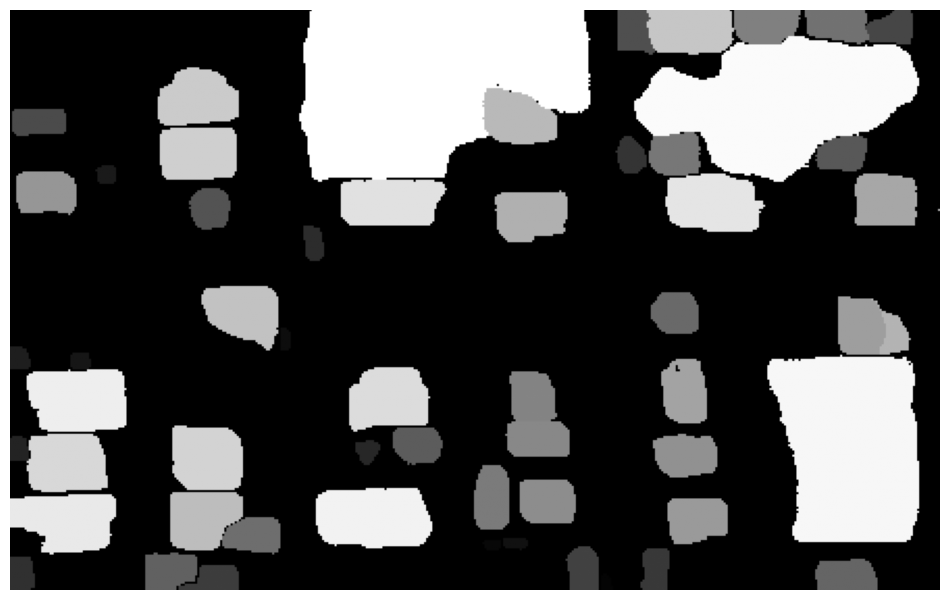

In [ ]:
sam2.show_masks(cmap="binary_r")

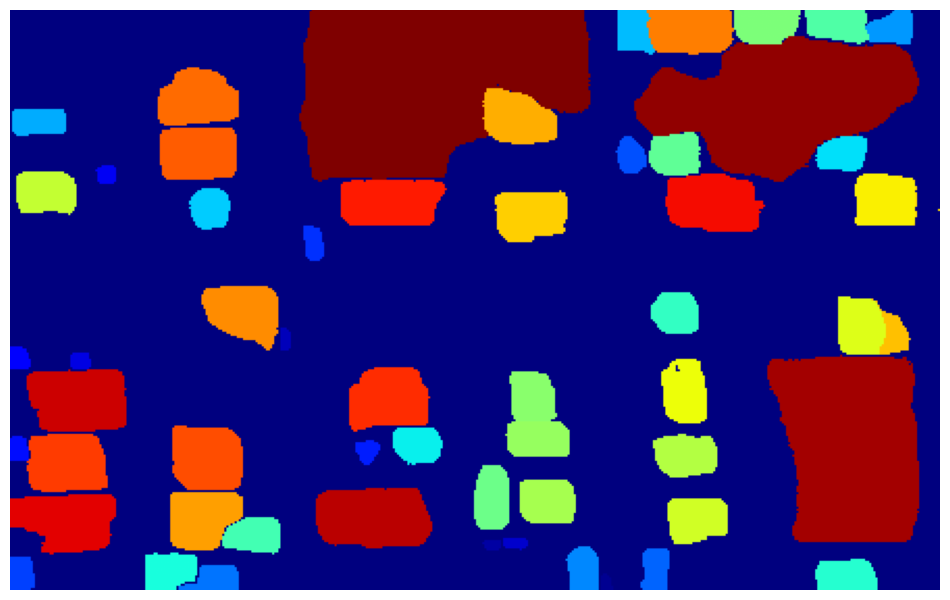

In [ ]:
sam2.show_masks(cmap="jet")

Show the object annotations (objects with random color) on the map.

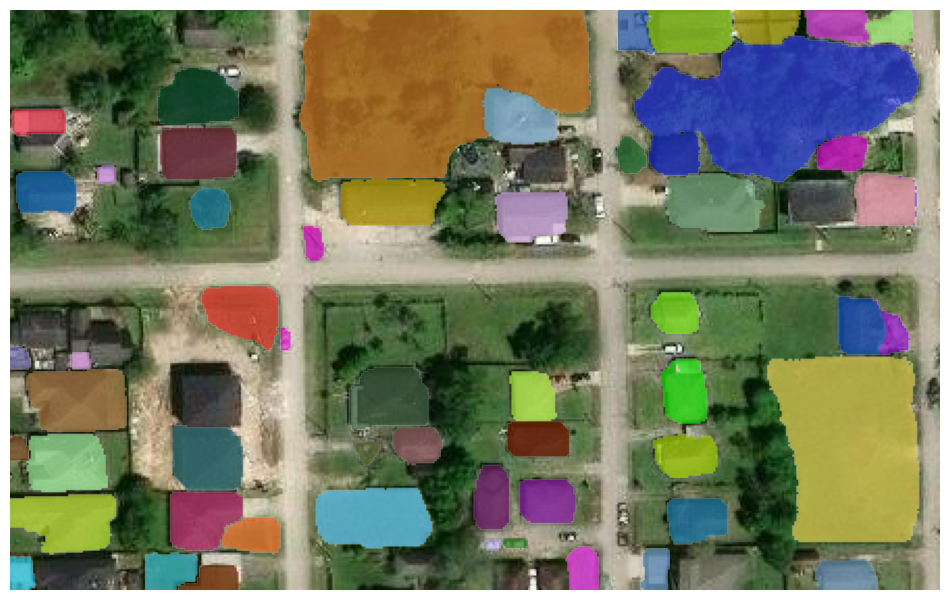

In [ ]:
sam2.show_anns(axis="off", alpha=0.7, output="annotations.tif")

### Compare Original and Segmented Images

Use an interactive slider to compare the original drone imagery with the SAM segmentation results.

In [ ]:
leafmap.image_comparison(
    ortho_image_10cm,
    "annotations.tif",
    label1="Drone Imagery",
    label2="Image Segmentation",
)

Add segmentation result to the map.

In [ ]:
m = leafmap.Map()
m.add_raster(ortho_image_10cm, layer_name="Ortho Imagery 202206")
m.add_raster("masks.tif", colormap="jet", layer_name="Masks", nodata=0, opacity=0.7)
m

Convert the object masks to vector format, such as GeoPackage, Shapefile, or GeoJSON.

In [ ]:
sam2.raster_to_vector("masks.tif", "masks.gpkg")

In [ ]:
m.add_vector("masks.gpkg", layer_name="Objects")

### Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [ ]:
sam2 = SamGeo2(
    model_id="sam2-hiera-large",
    apply_postprocessing=False,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25,
    use_m2m=True,
)

In [ ]:
sam2.generate(ortho_image_10cm, output="masks2.tif")

In [ ]:
sam2.show_masks(cmap="jet")

![image](https://github.com/user-attachments/assets/ff07bff9-f0d1-41c6-a641-ce9f4734fd61)

In [ ]:
sam2.show_anns(axis="off", alpha=0.7, output="annotations2.tif")

![image](https://github.com/user-attachments/assets/1e1df62c-ec44-4c5e-aa5a-4025d078ff6b)

In [ ]:
leafmap.image_comparison(
    ortho_image_10cm,
    "annotations2.tif",
    label1="Image",
    label2="Image Segmentation",
)

Remove small objects.

In [ ]:
da, gdf = sam2.region_groups(
    "masks2.tif",
    connectivity=1,
    min_size=10,
    max_size=2000,
    intensity_image="chm_202206.tif",
    out_image="objects.tif",
    out_csv="objects.csv",
    out_vector="objects.gpkg",
)

In [ ]:
m = leafmap.Map()
m.add_raster(ortho_image_10cm, layer_name="Ortho Imagery 202206")
m.add_vector("objects.gpkg", layer_name="Objects")
m

### Using box prompts

Restart the Runtime to avoid the VRAM allocation issue.

In [ ]:
import leafmap
from samgeo import SamGeo

In [ ]:
ortho_image_10cm = "ortho_image_202206_10cm.tif"
geojson = "tree_boundaries.geojson"

In [ ]:
gdf = leafmap.geojson_to_gdf(geojson)
gdf.head()

In [ ]:
m = leafmap.Map()
m.add_raster(ortho_image_10cm, layer_name="image")
style = {
    "color": "#ffff00",
    "weight": 2,
    "fillColor": "#7c4185",
    "fillOpacity": 0,
}
m.add_vector(geojson, style=style, zoom_to_layer=True, layer_name="Bounding boxes")
m

In [ ]:
sam = SamGeo(
    model_type="vit_h",
    automatic=False,
    sam_kwargs=None,
)

In [ ]:
sam.set_image(ortho_image_10cm)

In [ ]:
sam.predict(
    boxes=geojson, point_crs="EPSG:4326", output="tree_masks.tif", dtype="uint16"
)

In [ ]:
m.add_raster(
    "tree_masks.tif", cmap="jet", nodata=0, opacity=0.5, layer_name="Tree masks"
)
m

![image](https://github.com/user-attachments/assets/0a9b794d-cf94-4e5c-9134-8799e67d338c)

## Training a Deep Learning Model for Tree Segmentation

While SAM provides zero-shot segmentation, sometimes you need a custom model trained on your specific data. In this section, we'll train a U-Net model to segment tree canopies using labeled training data.

### Why Train a Custom Model?

- **Domain-specific accuracy**: Custom models learn features specific to your task (e.g., tree canopies vs. general objects)
- **Consistency**: Produces consistent results across multiple images from the same sensor
- **Speed**: Once trained, inference is faster than running SAM on large datasets
- **Control**: You can tune the model to prioritize precision or recall based on your needs

In [ ]:
import geoai
import leafmap

### Prepare Training and Testing Datasets

Deep learning models require labeled training data. We'll use tree boundary vectors from D2S to create training labels, then split our data into training and testing sets.

In [ ]:
m = leafmap.Map()
m.add_raster("ortho_image_202206.tif", layer_name="Ortho Imagery 202206")
m.add_vector("tree_boundaries.geojson", layer_name="Tree Boundaries")
m

In [ ]:
# Define separate regions for training and testing
# Training: Use June 2022 imagery with tree boundaries
# Testing: Use December 2022 imagery to test model generalization
bbox = [-97.956252, 26.165315, -97.954992, 26.165883]

In [ ]:
ortho_image_202206 = "ortho_image_202206.tif"
ortho_image_202212 = "ortho_image_202212.tif"
train_raster_path = "ortho_image_202206_train.tif"
test_raster_path = "ortho_image_202212_test.tif"
train_vector_path = "tree_boundaries.geojson"

In [ ]:
# Clip training imagery to the training bbox
# Resolution: 2cm (0.02m) provides good detail for tree segmentation
train_image_array = leafmap.clip_raster(
    ortho_image_202206,
    geometry=bbox,
    geom_crs="EPSG:4326",
    resolution=0.02,  # 2cm resolution
    output=train_raster_path,
)

In [ ]:
test_image_array = leafmap.clip_raster(
    ortho_image_202212,
    geometry=bbox,
    geom_crs="EPSG:4326",
    resolution=0.02,
    output=test_raster_path,
)

### Generate Training Tiles

Neural networks typically work with fixed-size inputs. We'll split the large training image into 512x512 pixel tiles with 256-pixel overlap to ensure complete coverage.

In [ ]:
# Create training tiles from the imagery and tree boundaries
# This will generate image/label pairs for U-Net training
out_folder = "trees"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,  # Input imagery
    out_folder=out_folder,  # Output directory
    in_class_data=train_vector_path,  # Tree boundary labels
    tile_size=512,  # Size of each tile in pixels
    stride=256,  # Step between tiles (50% overlap)
    buffer_radius=0,  # No buffer around geometries
)

### Train the U-Net Model

Now we'll train a U-Net semantic segmentation model with a ResNet34 encoder (pretrained on ImageNet). This process includes:

- **Architecture**: U-Net with ResNet34 backbone for feature extraction
- **Training data**: 288 tiles split into 80% train / 20% validation
- **Optimization**: Adam optimizer with learning rate 0.001
- **Epochs**: 30 training epochs with best model checkpointing
- **Metrics**: IoU (Intersection over Union), F1-score, Precision, and Recall

Training on a GPU (T4 or better) typically takes 5-10 minutes for this dataset.

In [ ]:
# Train U-Net model
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=4,
    num_classes=2,  # background and trees
    batch_size=8,
    num_epochs=10,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

In [ ]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

![metrics](https://github.com/user-attachments/assets/17f13951-1805-43c9-8eac-0c74acd303cc)

```text
=== Performance Metrics Summary ===
IoU     - Best: 0.9454 | Final: 0.9420
F1      - Best: 0.9718 | Final: 0.9700
Precision - Best: 0.9715 | Final: 0.9700
Recall  - Best: 0.9722 | Final: 0.9702
Val Loss - Best: 0.0746 | Final: 0.0829
===================================
```

In [ ]:
model_path = f"{out_folder}/unet_models/best_model.pth"
masks_path = "ortho_image_202212_masks.tif"
probability_path = "probabilities.tif"

### Apply Model to Test Imagery

Use the trained model to predict tree canopies on the December 2022 test imagery. We'll save both:
- **Classification mask**: Final tree/background predictions
- **Probability map**: Per-pixel confidence scores for each class

In [ ]:
# Run inference on the test image using the trained model
geoai.semantic_segmentation(
    input_path=test_raster_path,  # Input test imagery
    output_path=masks_path,  # Output classification mask
    model_path=model_path,  # Path to trained model weights
    architecture="unet",  # Same architecture as training
    encoder_name="resnet34",  # Same encoder as training
    num_channels=4,  # RGB + NIR bands
    num_classes=2,  # Background (0) and trees (1)
    window_size=512,  # Process in 512x512 windows
    overlap=256,  # 50% overlap for smooth boundaries
    batch_size=8,  # Process 8 windows at a time
    probability_threshold=0.5,  # Confidence threshold for classification
    probability_path=probability_path,  # Save probability scores
)

### Visualize Results

Display the test imagery, predicted segmentation masks, and probability maps on an interactive map. The probability layer shows the model's confidence for each pixel (higher values = more confident).

In [ ]:
# Create an interactive map to visualize the results
m = leafmap.Map()

# Add the original test imagery as the base layer
m.add_raster(test_raster_path, layer_name="Ortho Imagery 202212")

# Add the segmentation mask (hidden by default)
m.add_raster(
    masks_path,
    colormap="jet",
    layer_name="Segmentation",
    nodata=0,
    visible=False,  # Hidden by default, can toggle on
)

# Add the probability map showing model confidence
# Band 2 contains the probability for class 1 (trees)
m.add_raster(
    probability_path,
    indexes=[2],  # Class 1 (tree) probability
    colormap="jet",  # Color scale: blue (low) to red (high confidence)
    opacity=0.5,  # Semi-transparent overlay
    layer_name="Tree Probability",
    nodata=0,
)

m

![image](https://github.com/user-attachments/assets/8bd2af2b-dd13-48c1-a4f1-c6bbe0faff00)

## Summary and Next Steps

In this workshop, you learned how to:

1. **Access and visualize drone imagery** from the Data to Science (D2S) platform
2. **Perform zero-shot segmentation** using SAM2 for automatic object detection
3. **Train custom deep learning models** (U-Net) for domain-specific segmentation tasks
4. **Apply trained models** to new imagery and evaluate results

### Key Takeaways

- **SAM2** is excellent for exploratory analysis and when you don't have training labels
- **Custom U-Net models** provide better accuracy for specific tasks when training data is available
- The **GeoAI package** simplifies the entire pipeline from data preparation to model deployment
- **Leafmap** makes it easy to visualize and interact with geospatial AI results

### Next Steps

- Apply these techniques to your own drone or satellite imagery
- Experiment with different model architectures (DeepLabV3+, FPN, etc.)
- Try transfer learning from pre-trained models on similar agricultural datasets
- Explore temporal analysis by comparing multiple flights over time
- Integrate with other geospatial analysis workflows (crop health, yield prediction, etc.)

### Resources

- **GeoAI Documentation**: https://opengeoai.org
- **Leafmap Documentation**: https://leafmap.org
- **SAMGeo Documentation**: https://samgeo.gishub.org
- **D2S website**: https://d2s.org
- **D2S Platform**: https://ps2.d2s.org
- **D2S STAC**: https://stac.d2s.org
- **D2S GitHub**: https://github.com/gdslab/data-to-science

### Questions?

Feel free to reach out to the GeoAI community on GitHub.